In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#import libraries

import pandas as pd
import numpy as np
import re
import nltk
import pickle

In [4]:
from nltk.corpus import stopwords

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
from sklearn.svm import LinearSVC

In [8]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
nltk.download('punkt')
nltk.download('stopwords')  #downlaoad nltk data

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
df = pd.read_csv("C:\\Users\\raksh\\OneDrive\\Desktop\\Sentimal_analysis\\data\\IMDB Dataset.csv\\IMDB Dataset.csv", engine='python', on_bad_lines='skip')  #load dataset

In [12]:
print("\nFirst 5 Rows:\n")
print(df.head())


First 5 Rows:

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [13]:
print("\nDataset Shape:\n")
print(df.shape)


Dataset Shape:

(50000, 2)


In [14]:
print("\nColumn Names:\n")
print(df.columns)


Column Names:

Index(['review', 'sentiment'], dtype='str')


In [15]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

review       0
sentiment    0
dtype: int64


In [16]:
print("\nSentiment Distribution:\n")
print(df['sentiment'].value_counts())


Sentiment Distribution:

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [17]:
#sample review

print("\nSample Review:\n")
print(df['review'][0])

print("\nSentiment:\n")
print(df['sentiment'][0])


Sample Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [18]:
##Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()  # Convert to lowercase

    text = re.sub(r'<.*?>', '', text)   # Remove HTML tags

    text = re.sub(r'[^a-zA-Z]', ' ', text)   # Remove punctuation and numbers

    words = text.split()    # Split into words

    words = [word for word in words if word not in stop_words]  # Remove stopwords

    return " ".join(words)   # Join words back

In [19]:
# Apply preprocessing
df['clean_review'] = df['review'].apply(clean_text)
print("\nText Cleaning Completed")


Text Cleaning Completed


In [20]:
#Before Cleaning
print("\nOriginal Review:\n")
print(df['review'][0])

#After Cleaning
print("\nCleaned Review:\n")
print(df['clean_review'][0])


Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the sho

In [21]:
#Convert lables to numbers
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

print("\nLabel Encoding Completed")


Label Encoding Completed


In [22]:
#Feature Engineering Using TF-IDF

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

print("\nTF-IDF Vectorization Completed")


TF-IDF Vectorization Completed


In [23]:
#train - test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain-Test Split Completed")

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)


Train-Test Split Completed

X_train Shape: (40000, 10000)
X_test Shape: (10000, 10000)


In [24]:
#Model traing - Linear SVM

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
print("\nModel Training Completed")


Model Training Completed


In [25]:
#Model Prediction

y_pred = svm_model.predict(X_test)

print("\nPrediction Completed")


Prediction Completed


In [26]:
#Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:")
print(accuracy)



Model Accuracy:
0.8798


In [27]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[4320  641]
 [ 561 4478]]


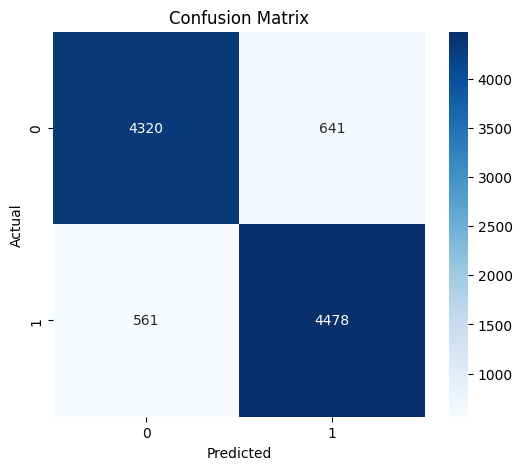

In [28]:
#Confusion matrix visualization
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
#Classification report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [30]:
sample = ["This movie was absolutely fantastic"]

sample_vector = tfidf.transform(sample)

prediction = svm_model.predict(sample_vector)

print("\nCustom Review Prediction:\n")

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😡")



Custom Review Prediction:

Positive Review 😊


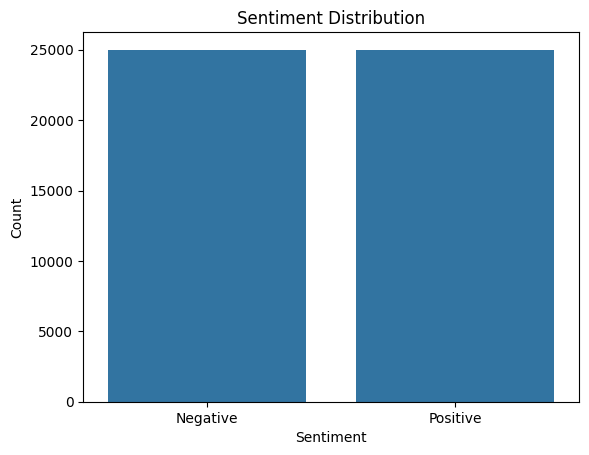

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='sentiment',
    data=df
)

plt.xticks(
    ticks=[0,1],
    labels=['Negative','Positive']
)

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.title("Sentiment Distribution")

plt.show()

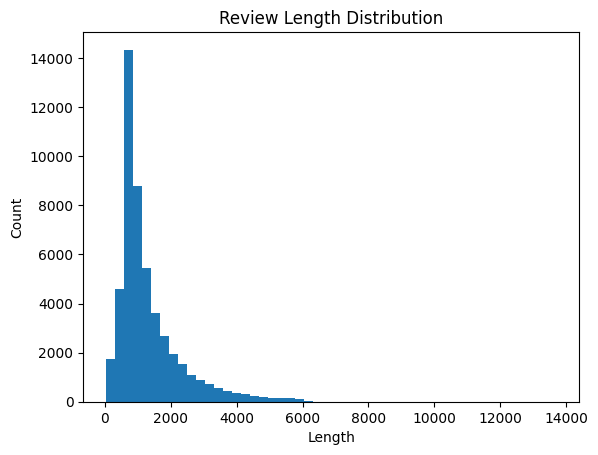

In [32]:
#Shows how long reviews are
df['review_length'] = df['review'].apply(len)

plt.hist(df['review_length'], bins=50)

plt.title("Review Length Distribution")

plt.xlabel("Length")

plt.ylabel("Count")

plt.show()

In [33]:
import sys

!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
positive_reviews = " ".join(
    df[df['sentiment'] == 1]['review']
)
negative_reviews = " ".join(
    df[df['sentiment'] == 0]['review']
)

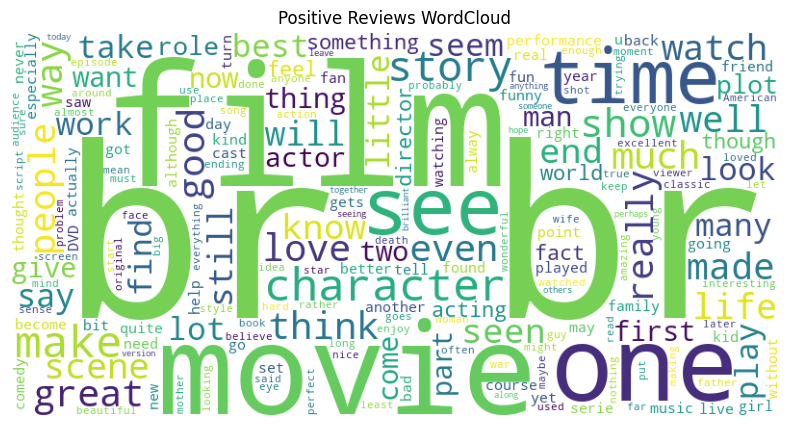

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews WordCloud")

plt.show()

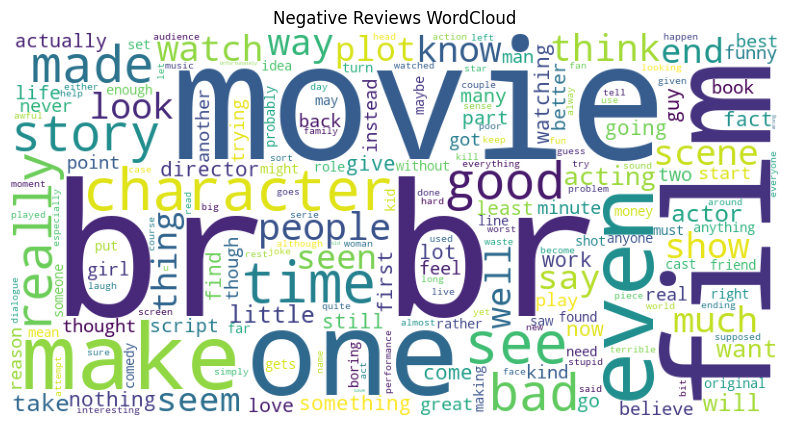

In [36]:

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Reviews WordCloud")

plt.show()

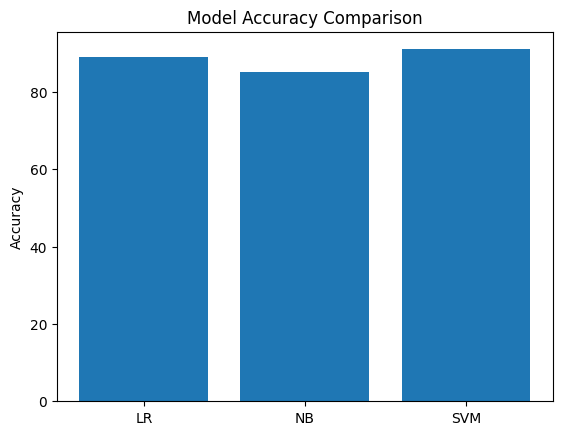

In [37]:
# Comparison of model accuracies of Logistic Regression, Naive Bayes and SVM
models = ['LR', 'NB', 'SVM']

scores = [89, 85, 91]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [49]:
import os
import pickle

os.makedirs('models', exist_ok=True)

# Save trained SVM model
with open('models/model.pkl', 'wb') as model_file:
    pickle.dump(svm_model, model_file)

# Save TF-IDF vectorizer
with open('models/vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(tfidf, vec_file)

print("Model and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!


In [40]:
sample = "This movie was amazing and fantastic"
cleaned = clean_text(sample)
vector = tfidf.transform([cleaned])
prediction = svm_model.predict(vector)
print(prediction)

[1]


In [41]:
sample = "Worst movie error"
cleaned = clean_text(sample)
vector = tfidf.transform([cleaned])
prediction = svm_model.predict(vector)
print(prediction)

[0]


In [42]:
print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [43]:
print(df[['clean_review', 'sentiment']].head(10))

                                        clean_review  sentiment
0  one reviewers mentioned watching oz episode ho...          1
1  wonderful little production filming technique ...          1
2  thought wonderful way spend time hot summer we...          1
3  basically family little boy jake thinks zombie...          0
4  petter mattei love time money visually stunnin...          1
5  probably time favorite movie story selflessnes...          1
6  sure would like see resurrection dated seahunt...          1
7  show amazing fresh innovative idea first aired...          0
8  encouraged positive comments film looking forw...          0
9  like original gut wrenching laughter like movi...          1
